In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (20, 10)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 18

In [2]:
from pathlib import Path
root_dir = Path().resolve()

parquet_path = root_dir / "artifacts" / "oos_predictions_3.parquet"
df = pd.read_parquet(parquet_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Date', 'Ticker'])

print(f"Total Predictions : {len(df):,}")
print(f"Timeline          : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Trading Days      : {df['Date'].nunique()}")

Total Predictions : 631,430
Timeline          : 2021-01-29 to 2026-06-23
Trading Days      : 1355


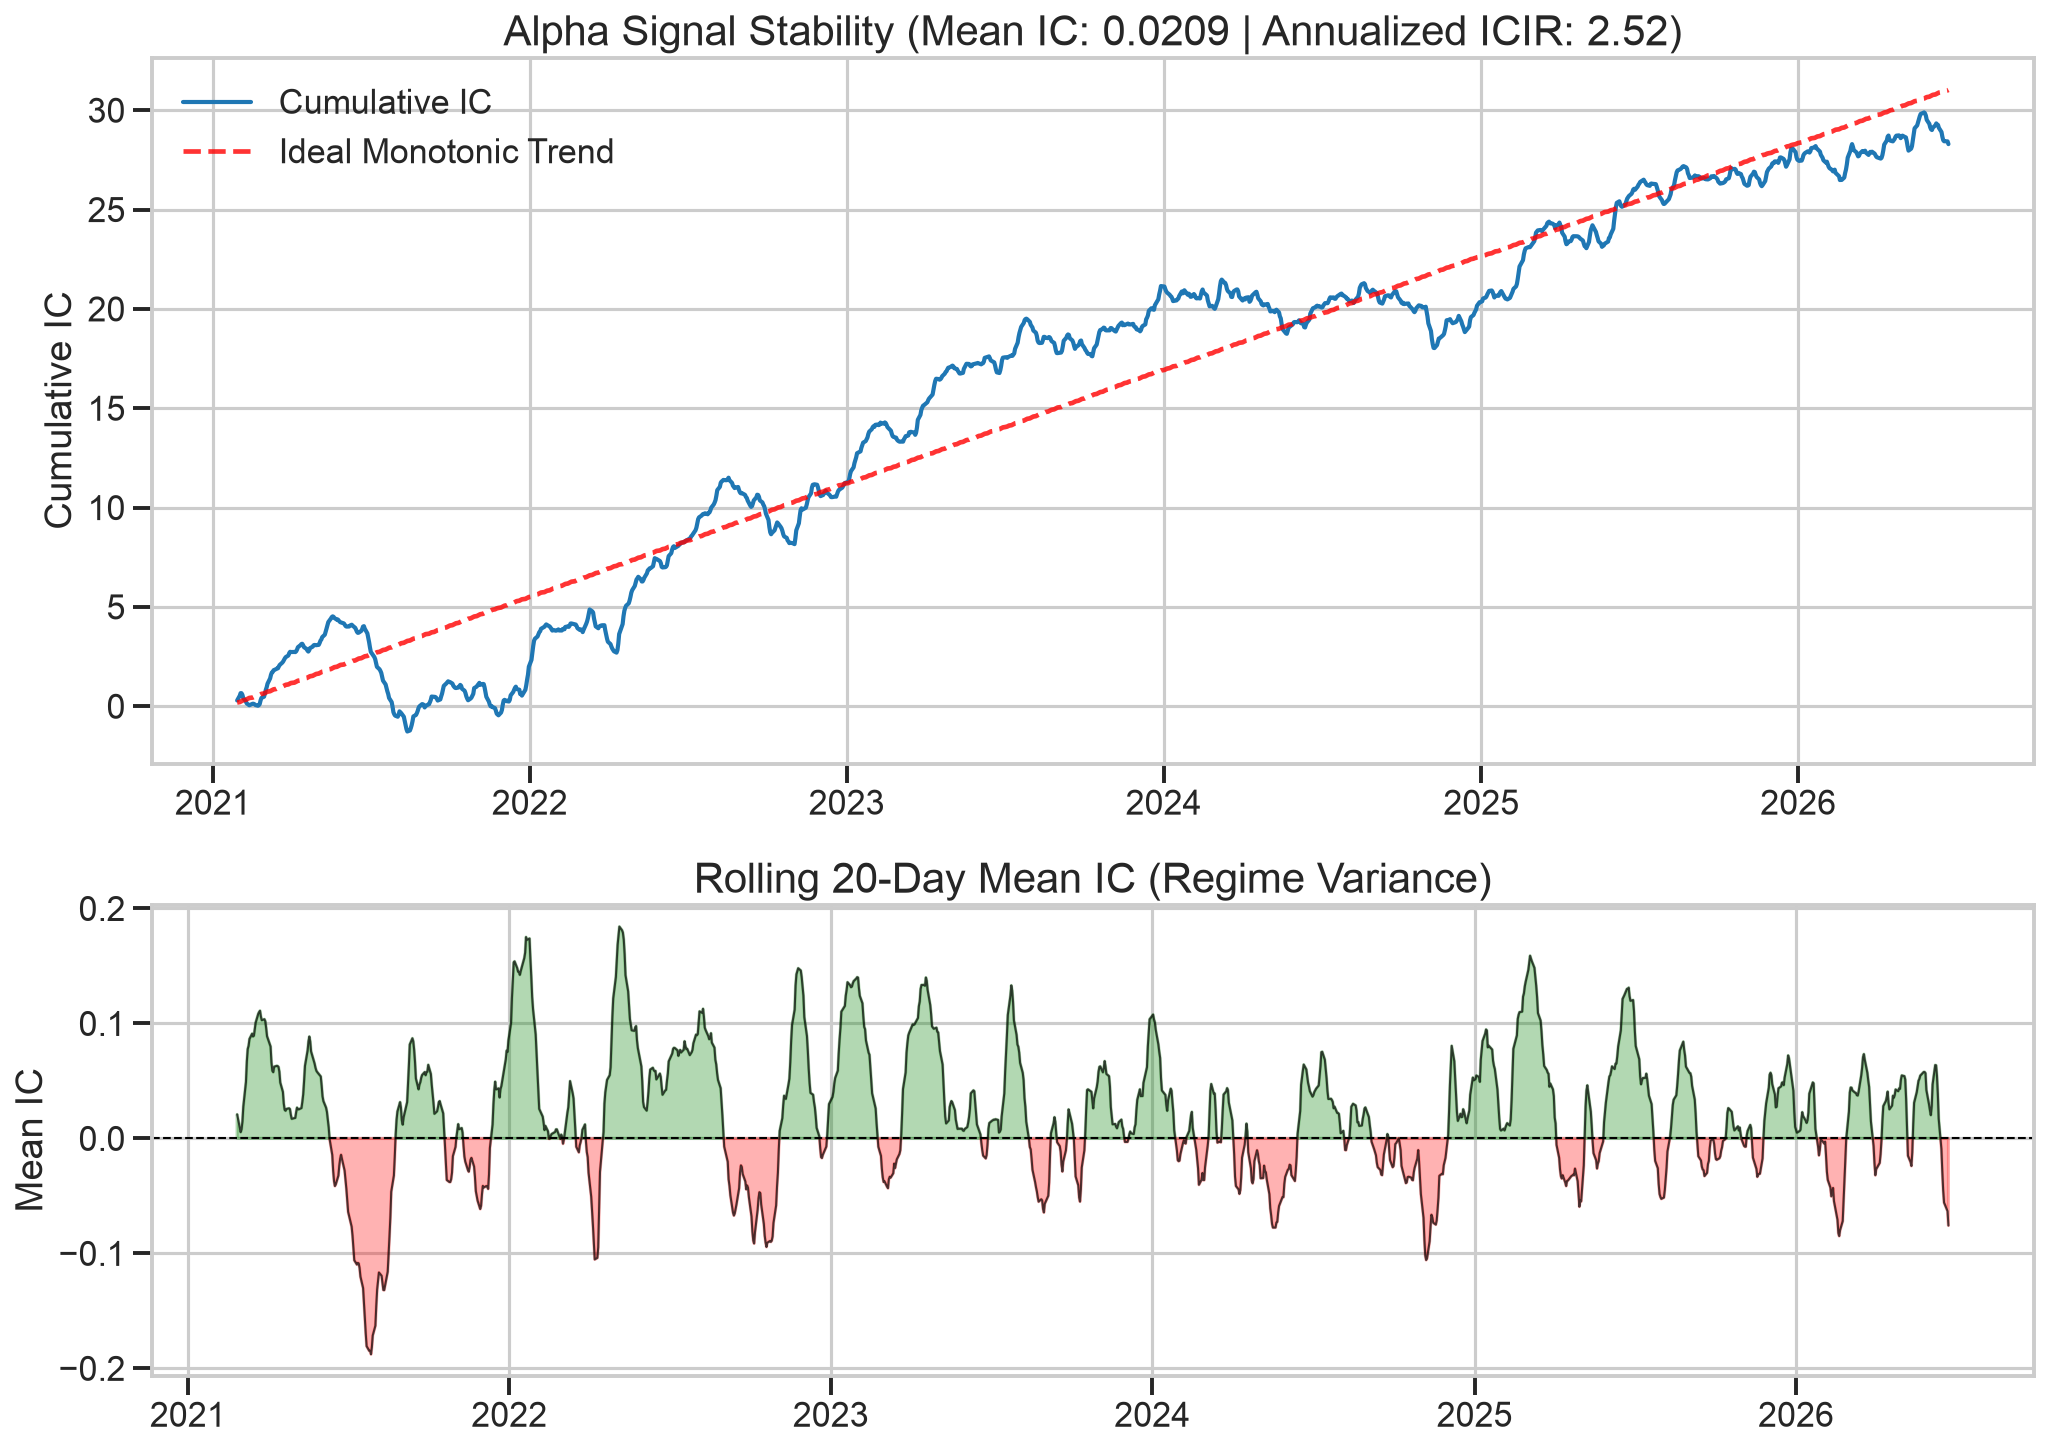

In [3]:
daily_ic = []
for date, group in df.groupby('Date'):
    if len(group) > 20 and group['Pred_Alpha'].std() > 1e-6:
        ic, _ = spearmanr(group['Pred_Alpha'], group['Target_5D_Z'])
        if not np.isnan(ic):
            daily_ic.append({'Date': date, 'IC': ic})

ic_df = pd.DataFrame(daily_ic).set_index('Date')
ic_df['Cum_IC'] = ic_df['IC'].cumsum()
ic_df['Rolling_IC_20D'] = ic_df['IC'].rolling(window=20).mean()

mean_ic = ic_df['IC'].mean()
ic_std = ic_df['IC'].std()
icir = (mean_ic / ic_std) * np.sqrt(252)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1.5, 1]})

# Cumulative IC plot with linear fit
ax1.plot(ic_df.index, ic_df['Cum_IC'], color='#1f77b4', linewidth=2, label='Cumulative IC')
z = np.polyfit(range(len(ic_df)), ic_df['Cum_IC'], 1)
p = np.poly1d(z)
ax1.plot(ic_df.index, p(range(len(ic_df))), "r--", alpha=0.8, label="Ideal Monotonic Trend")
ax1.set_title(f"Alpha Signal Stability (Mean IC: {mean_ic:.4f} | Annualized ICIR: {icir:.2f})")
ax1.set_ylabel("Cumulative IC")
ax1.legend()

# Rolling 20-Day mean IC
ax2.fill_between(ic_df.index, ic_df['Rolling_IC_20D'], 0, 
                 where=(ic_df['Rolling_IC_20D'] > 0), color='green', alpha=0.3, interpolate=True)
ax2.fill_between(ic_df.index, ic_df['Rolling_IC_20D'], 0, 
                 where=(ic_df['Rolling_IC_20D'] <= 0), color='red', alpha=0.3, interpolate=True)
ax2.plot(ic_df.index, ic_df['Rolling_IC_20D'], color='black', linewidth=1, alpha=0.7)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title("Rolling 20-Day Mean IC (Regime Variance)")
ax2.set_ylabel("Mean IC")

plt.tight_layout()
plt.show()

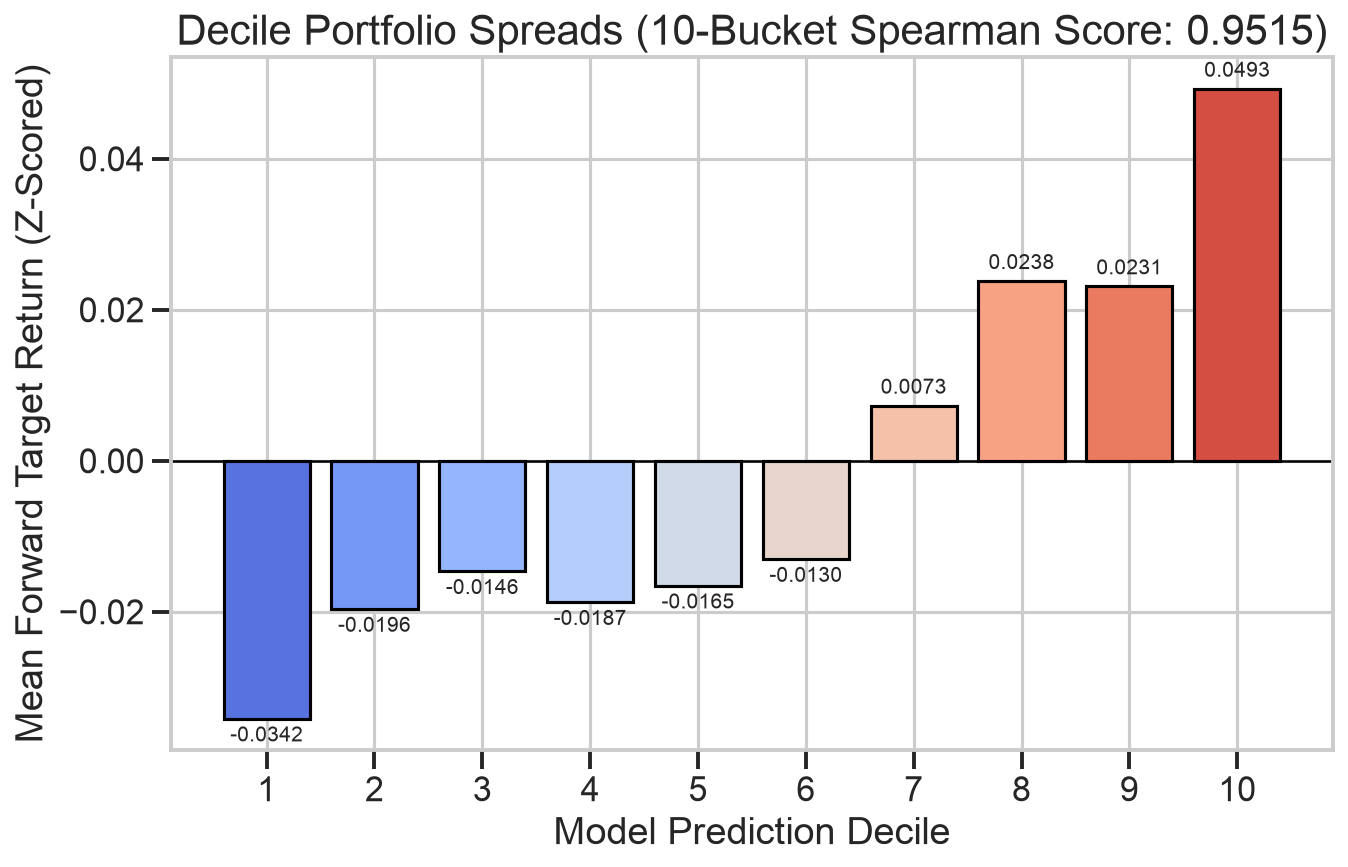

In [4]:
df['Rank'] = df.groupby('Date')['Pred_Alpha'].rank(method='first')
df['Decile'] = df.groupby('Date')['Rank'].transform(
    lambda x: pd.qcut(x, 10, labels=False) + 1
)

# Calculate mean realized residual return per decile
decile_returns = df.groupby('Decile')['Target_5D_Z'].mean()
mono_corr, _ = spearmanr(decile_returns.index, decile_returns.values)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("coolwarm", len(decile_returns))
bars = plt.bar(decile_returns.index, decile_returns.values, color=colors, edgecolor='black')

plt.axhline(0, color='black', linewidth=1.2)
plt.title(f"Decile Portfolio Spreads (10-Bucket Spearman Score: {mono_corr:.4f})")
plt.xlabel("Model Prediction Decile")
plt.ylabel("Mean Forward Target Return (Z-Scored)")
plt.xticks(range(1, 11))

# Value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        yval + (0.001 if yval > 0 else -0.001), 
        f'{yval:.4f}', 
        ha='center', 
        va='bottom' if yval > 0 else 'top', 
        fontsize=10
    )
        
plt.show()

In [5]:
from pandas import DataFrame

COST_BPS = 10 
TOP_K = 40

def compute_forward_returns(df: DataFrame, horizon=5):
    """
    For each day t, target is the sum of Log_Ret from t+1 to t+horizon.
    """
    df = df.sort_values(['Ticker', 'Date']).copy()
    df['Ret_Fwd_5'] = df.groupby('Ticker')['Log_Ret'].transform(
        lambda x: x.rolling(horizon).sum().shift(-horizon)
    )
    return df

def run_long_short_backtest_fixed(df: DataFrame, top_k=TOP_K, cost_bps=COST_BPS, rebalance_freq=5):
    """
    Rebalance every `rebalance_freq` days using predictions to select top/bottom stocks.
    Return is forward return from Log_Ret.
    """
    df = compute_forward_returns(df, horizon=rebalance_freq)
    df = df.dropna(subset=['Ret_Fwd_5', 'Pred_Alpha'])
    
    dates = sorted(df['Date'].unique())
    rebalance_dates = dates[::rebalance_freq]
    
    portfolio_records = []
    for date in rebalance_dates:
        day_df = df[df['Date'] == date]
        if len(day_df) < top_k * 2:
            continue
        
        ranked = day_df.sort_values('Pred_Alpha', ascending=False)
        longs = ranked.head(top_k)
        shorts = ranked.tail(top_k)
        
        long_ret = longs['Ret_Fwd_5'].mean()
        short_ret = shorts['Ret_Fwd_5'].mean()
        gross_ret = (long_ret - short_ret) * 0.5  # 50% each leg
        
        net_ret = gross_ret - (cost_bps / 10000.0)
        
        portfolio_records.append({
            'Date': date,
            'Gross_Ret': gross_ret,
            'Net_Ret': net_ret
        })
    
    pnl_df = pd.DataFrame(portfolio_records).set_index('Date')
    
    pnl_df['Equity'] = (1 + pnl_df['Net_Ret']).cumprod()
    roll_max = pnl_df['Equity'].cummax()
    pnl_df['Drawdown'] = (pnl_df['Equity'] - roll_max) / roll_max
    
    pnl_df['Rolling_Sharpe'] = (pnl_df['Net_Ret'].rolling(24).mean() / 
                                pnl_df['Net_Ret'].rolling(24).std()) * np.sqrt(252 / rebalance_freq)
    
    return pnl_df

pnl_df_fixed = run_long_short_backtest_fixed(df, top_k=TOP_K, cost_bps=COST_BPS, rebalance_freq=5)

In [6]:
# Extreme Decile Directional Hit Rate
rebalance_dates = sorted(df['Date'].unique())[::5]  # 5-day intervals
hit_records = []

for date in rebalance_dates:
    day_df = df[df['Date'] == date]
    if day_df.empty:
        continue

    d10 = day_df[day_df['Decile'] == 10]['Target_5D_Z'].mean()
    d1 = day_df[day_df['Decile'] == 1]['Target_5D_Z'].mean()
    hit_records.append(1 if d10 > d1 else 0)

hit_rate = np.mean(hit_records)
print(f"\nDecile 10 > Decile 1 Hit Rate: {hit_rate * 100:.2f}%")


Decile 10 > Decile 1 Hit Rate: 56.83%


# Kendall's Tau


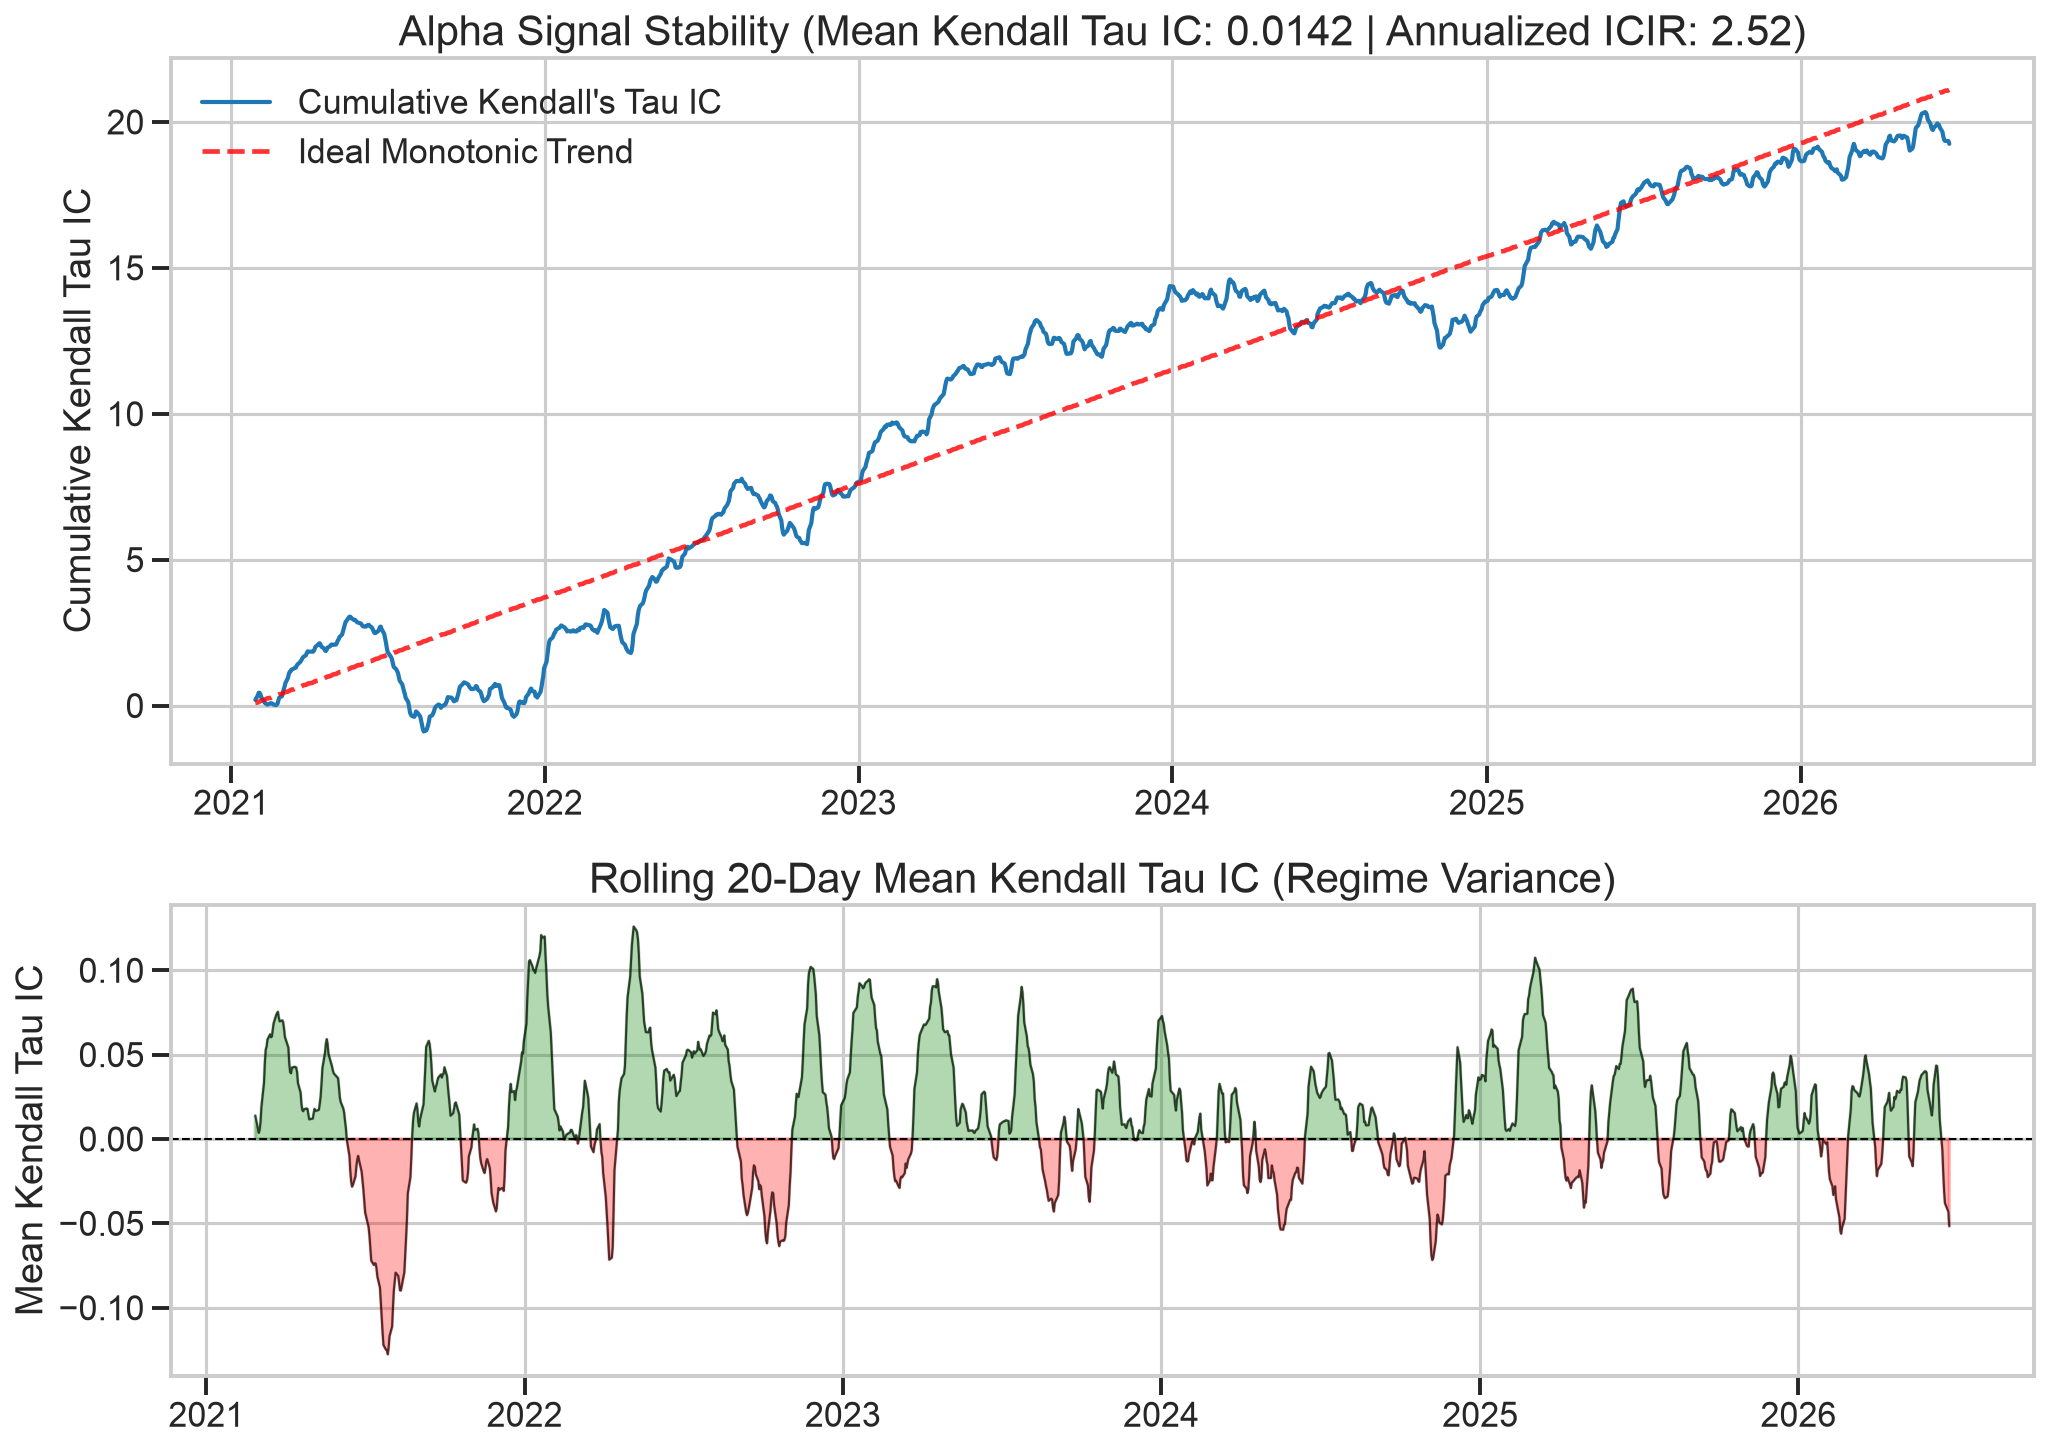

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

# Calculate daily Kendall's Tau Information Coefficient
daily_kt_ic = []
for date, group in df.groupby('Date'):
    if len(group) > 20 and group['Pred_Alpha'].std() > 1e-6:
        ic, _ = kendalltau(group['Pred_Alpha'], group['Target_5D_Z'])
        if not np.isnan(ic):
            daily_kt_ic.append({'Date': date, 'IC': ic})

kt_ic_df = pd.DataFrame(daily_kt_ic).set_index('Date')
kt_ic_df['Cum_IC'] = kt_ic_df['IC'].cumsum()
kt_ic_df['Rolling_IC_20D'] = kt_ic_df['IC'].rolling(window=20).mean()

mean_kt_ic = kt_ic_df['IC'].mean()
kt_ic_std = kt_ic_df['IC'].std()
# Annualized ICIR for Kendall's Tau based on rebalance frequency
kt_icir = (mean_kt_ic / kt_ic_std) * np.sqrt(252)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1.5, 1]})

ax1.plot(kt_ic_df.index, kt_ic_df['Cum_IC'], color='#1f77b4', linewidth=2, label="Cumulative Kendall's Tau IC")
z = np.polyfit(range(len(kt_ic_df)), kt_ic_df['Cum_IC'], 1)
p = np.poly1d(z)
ax1.plot(kt_ic_df.index, p(range(len(kt_ic_df))), "r--", alpha=0.8, label="Ideal Monotonic Trend")
ax1.set_title(f"Alpha Signal Stability (Mean Kendall Tau IC: {mean_kt_ic:.4f} | Annualized ICIR: {kt_icir:.2f})")
ax1.set_ylabel("Cumulative Kendall Tau IC")
ax1.legend()

ax2.fill_between(kt_ic_df.index, kt_ic_df['Rolling_IC_20D'], 0, 
                 where=(kt_ic_df['Rolling_IC_20D'] > 0), color='green', alpha=0.3, interpolate=True)
ax2.fill_between(kt_ic_df.index, kt_ic_df['Rolling_IC_20D'], 0, 
                 where=(kt_ic_df['Rolling_IC_20D'] <= 0), color='red', alpha=0.3, interpolate=True)
ax2.plot(kt_ic_df.index, kt_ic_df['Rolling_IC_20D'], color='black', linewidth=1, alpha=0.7)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title("Rolling 20-Day Mean Kendall Tau IC (Regime Variance)")
ax2.set_ylabel("Mean Kendall Tau IC")

plt.tight_layout()
plt.show()


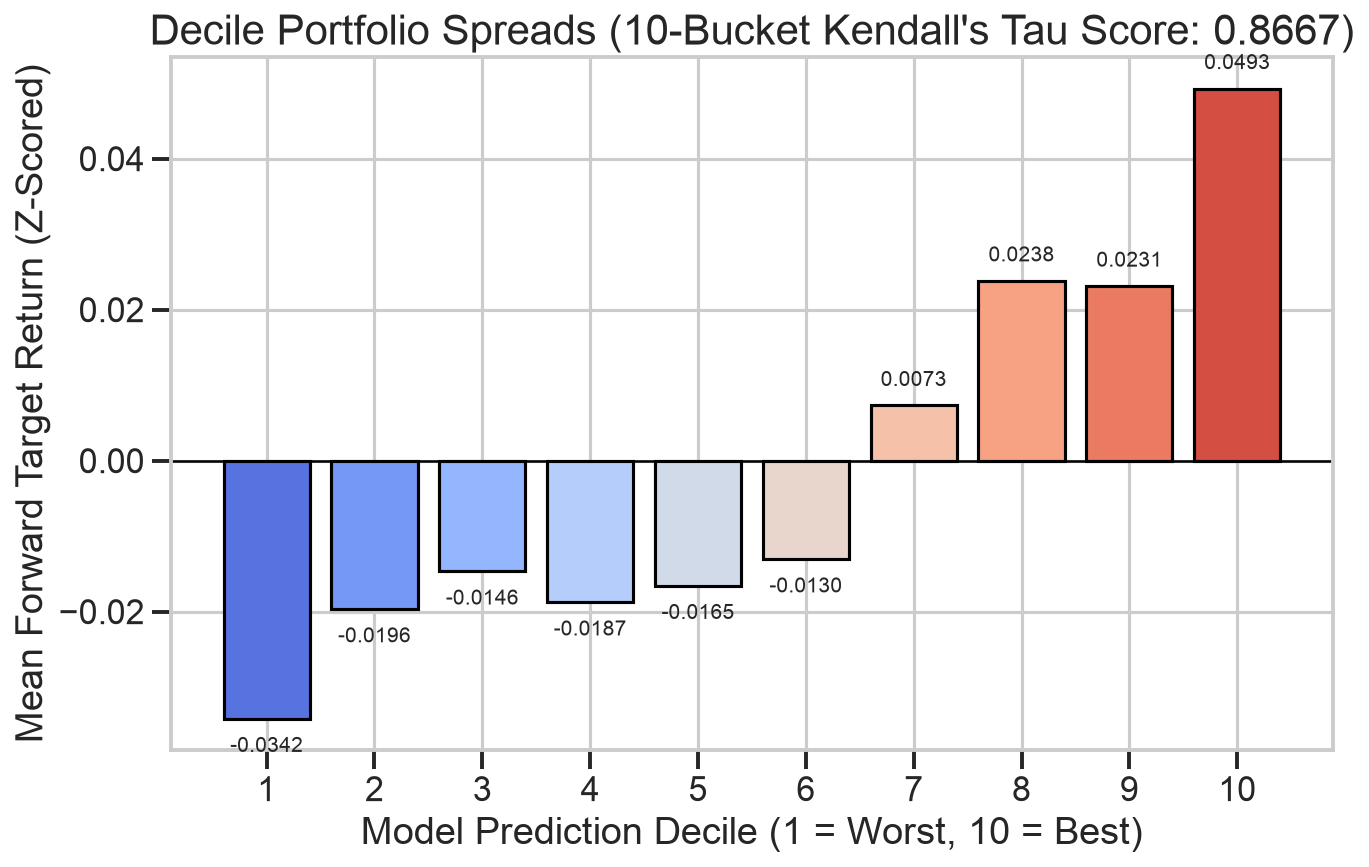

In [8]:
df['Rank'] = df.groupby('Date')['Pred_Alpha'].rank(method='first')
df['Decile'] = df.groupby('Date')['Rank'].transform(
    lambda x: pd.qcut(x, 10, labels=False) + 1
)

decile_returns = df.groupby('Decile')['Target_5D_Z'].mean()

# Calculate Kendall's Tau for deciles
mono_kt_corr, _ = kendalltau(decile_returns.index, decile_returns.values)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("coolwarm", len(decile_returns))
bars = plt.bar(decile_returns.index, decile_returns.values, color=colors, edgecolor='black')

plt.axhline(0, color='black', linewidth=1.2)
plt.title(f"Decile Portfolio Spreads (10-Bucket Kendall's Tau Score: {mono_kt_corr:.4f})")
plt.xlabel("Model Prediction Decile (1 = Worst, 10 = Best)")
plt.ylabel("Mean Forward Target Return (Z-Scored)")
plt.xticks(range(1, 11))

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (0.002 if yval > 0 else -0.005), 
             f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

plt.show()


In [9]:
pnl = pnl_df_fixed

ann_ret = pnl['Net_Ret'].mean() * (252 / 5)  
ann_vol = pnl['Net_Ret'].std() * np.sqrt(252 / 5)
sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan
neg_ret = pnl[pnl['Net_Ret'] < 0]['Net_Ret']
sortino = ann_ret / (neg_ret.std() * np.sqrt(252 / 5)) if len(neg_ret) > 0 else np.nan
max_dd = pnl['Drawdown'].min()
calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

# Tạo bảng tổng hợp các chỉ số hiệu suất quan trọng
metrics_dict = {
    "Total Rebalance Periods": len(pnl),
    "Mean Purged Kendall Tau IC": f"{mean_kt_ic:.5f}",
    "Annualized ICIR (Kendall)": f"{kt_icir:.2f}",
    "Decile Monotonicity (Kendall Tau)": f"{mono_kt_corr:.4f}",
    "Annualized Return (Net)": f"{ann_ret * 100:.2f}%",
    "Annualized Volatility": f"{ann_vol * 100:.2f}%",
    "Annualized Sharpe": f"{sharpe:.2f}",
    "Sortino Ratio": f"{sortino:.2f}",
    "Max Drawdown": f"{max_dd * 100:.2f}%",
    "Calmar Ratio": f"{calmar:.2f}"
}
summary_df_fixed = pd.DataFrame(list(metrics_dict.items()), columns=["Metric", "Value"]).set_index("Metric")
display(summary_df_fixed)

,Value
Metric,
Total Rebalance Periods,270
Mean Purged Kendall Tau IC,0.01421
Annualized ICIR (Kendall),2.52
Decile Monotonicity (Kendall Tau),0.8667
Annualized Return (Net),-1.00%
Annualized Volatility,9.20%
Annualized Sharpe,-0.11
Sortino Ratio,-0.17
Max Drawdown,-19.77%


In [10]:
# Tính toán Portfolio Turnover hàng năm
dates = sorted(df['Date'].unique())
rebalance_dates = dates[::5]

turnover_list = []
last_weights = pd.Series(dtype=float)

for date in rebalance_dates:
    day_df = df[df['Date'] == date]
    if len(day_df) < TOP_K * 2:
        continue
    
    ranked = day_df.sort_values('Pred_Alpha', ascending=False)
    longs = ranked.head(TOP_K)['Ticker'].tolist()
    shorts = ranked.tail(TOP_K)['Ticker'].tolist()
    
    # Thiết lập tỷ trọng: Long = +1/Top_K, Short = -1/Top_K
    current_weights = pd.Series(0.0, index=day_df['Ticker'].unique())
    current_weights.loc[longs] = 1.0 / TOP_K
    current_weights.loc[shorts] = -1.0 / TOP_K
    
    if not last_weights.empty:
        # Căn chỉ số cho việc tính chênh lệch vị thế
        all_tickers = current_weights.index.union(last_weights.index)
        w_curr = current_weights.reindex(all_tickers, fill_value=0.0)
        w_last = last_weights.reindex(all_tickers, fill_value=0.0)
        
        # Turnover trên 1 leg vị thế
        turnover = np.sum(np.abs(w_curr - w_last)) / 2.0
        turnover_list.append(turnover)
        
    last_weights = current_weights

mean_turnover_per_period = np.mean(turnover_list)
annualized_turnover = mean_turnover_per_period * (252 / 5)
print(f"Annualized Portfolio Turnover Rate: {annualized_turnover * 100:.2f}%")


Annualized Portfolio Turnover Rate: 2731.87%


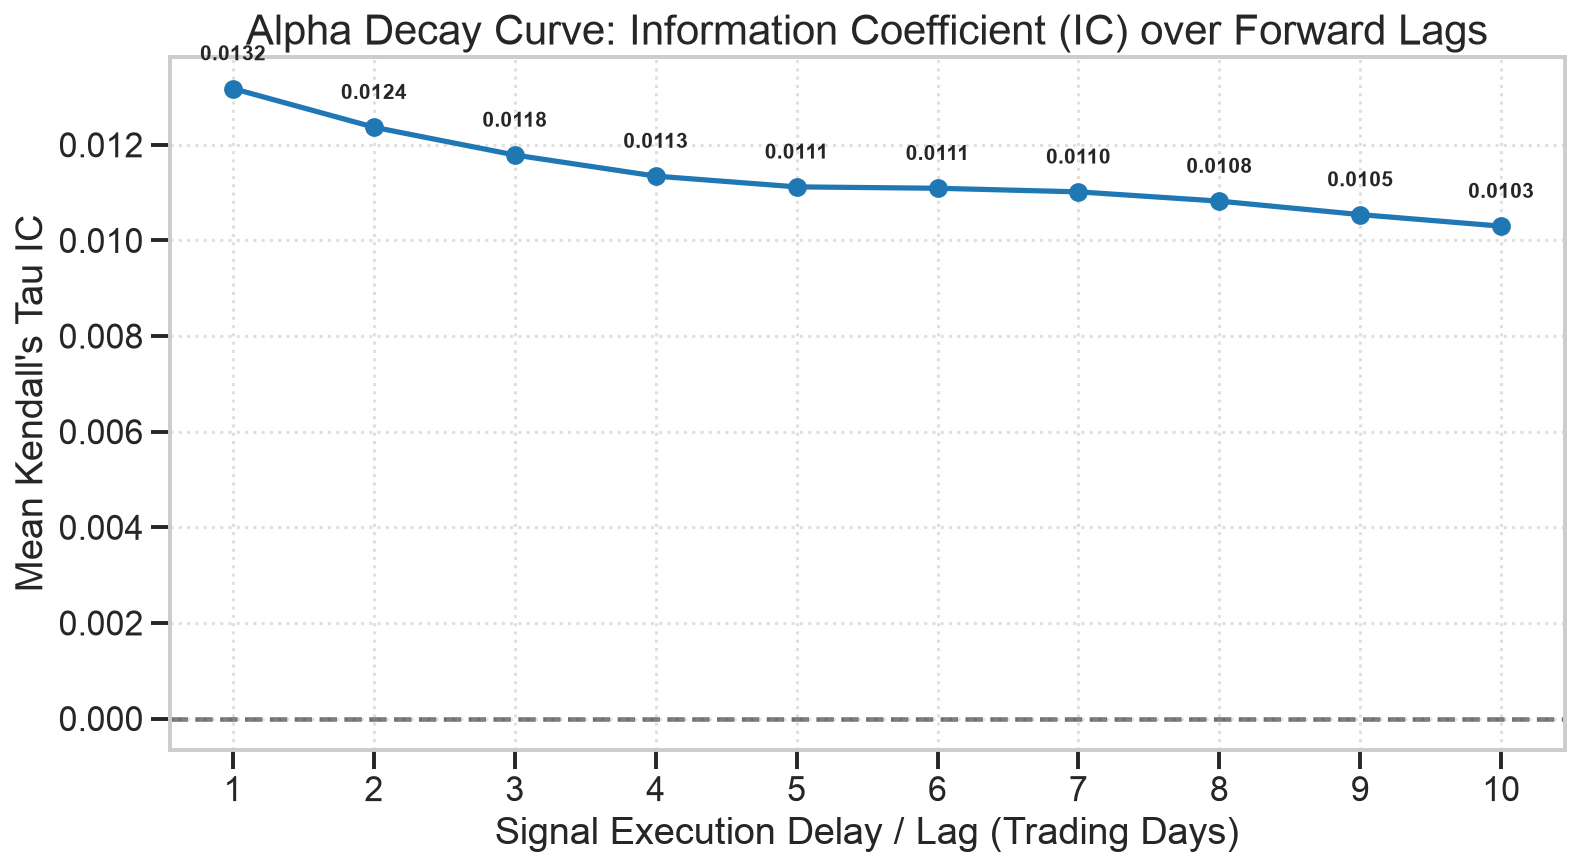

,Mean_Kendall_IC
Lag_Days,
1,0.013177
2,0.012368
3,0.011787
4,0.011345
5,0.011121
6,0.011091
7,0.011016
8,0.010822
9,0.010540


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

# Tính toán Alpha Decay (IC theo các mức Lag từ 1 đến 10 ngày)
max_lags = 10
decay_results = []

df_decay = df.sort_values(['Ticker', 'Date']).copy()

for lag in range(1, max_lags + 1):
    # Tính toán Forward Return dịch chuyển theo số ngày lag tương ứng
    df_decay[f'Target_5D_Z_Lag_{lag}'] = df_decay.groupby('Ticker')['Target_5D_Z'].shift(-lag)
    
    daily_ics = []
    for date, group in df_decay.groupby('Date'):
        target_col = f'Target_5D_Z_Lag_{lag}'
        valid_group = group.dropna(subset=['Pred_Alpha', target_col])
        
        if len(valid_group) > 20 and valid_group['Pred_Alpha'].std() > 1e-6:
            ic, _ = kendalltau(valid_group['Pred_Alpha'], valid_group[target_col])
            if not np.isnan(ic):
                daily_ics.append(ic)
                
    mean_ic_lag = np.mean(daily_ics) if daily_ics else 0.
    decay_results.append({'Lag_Days': lag, 'Mean_Kendall_IC': mean_ic_lag})

decay_df = pd.DataFrame(decay_results).set_index('Lag_Days')

plt.figure(figsize=(12, 6))
plt.plot(decay_df.index, decay_df['Mean_Kendall_IC'], marker='o', color='#1f77b4', linewidth=2.5, markersize=8, label="Alpha Decay (IC)")
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.title("Alpha Decay Curve: Information Coefficient (IC) over Forward Lags")
plt.xlabel("Signal Execution Delay / Lag (Trading Days)")
plt.ylabel("Mean Kendall's Tau IC")
plt.xticks(range(1, max_lags + 1))
plt.grid(True, linestyle=':', alpha=0.6)

for x, y in zip(decay_df.index, decay_df['Mean_Kendall_IC']):
    plt.text(x, y + 0.0005, f'{y:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()
display(decay_df)


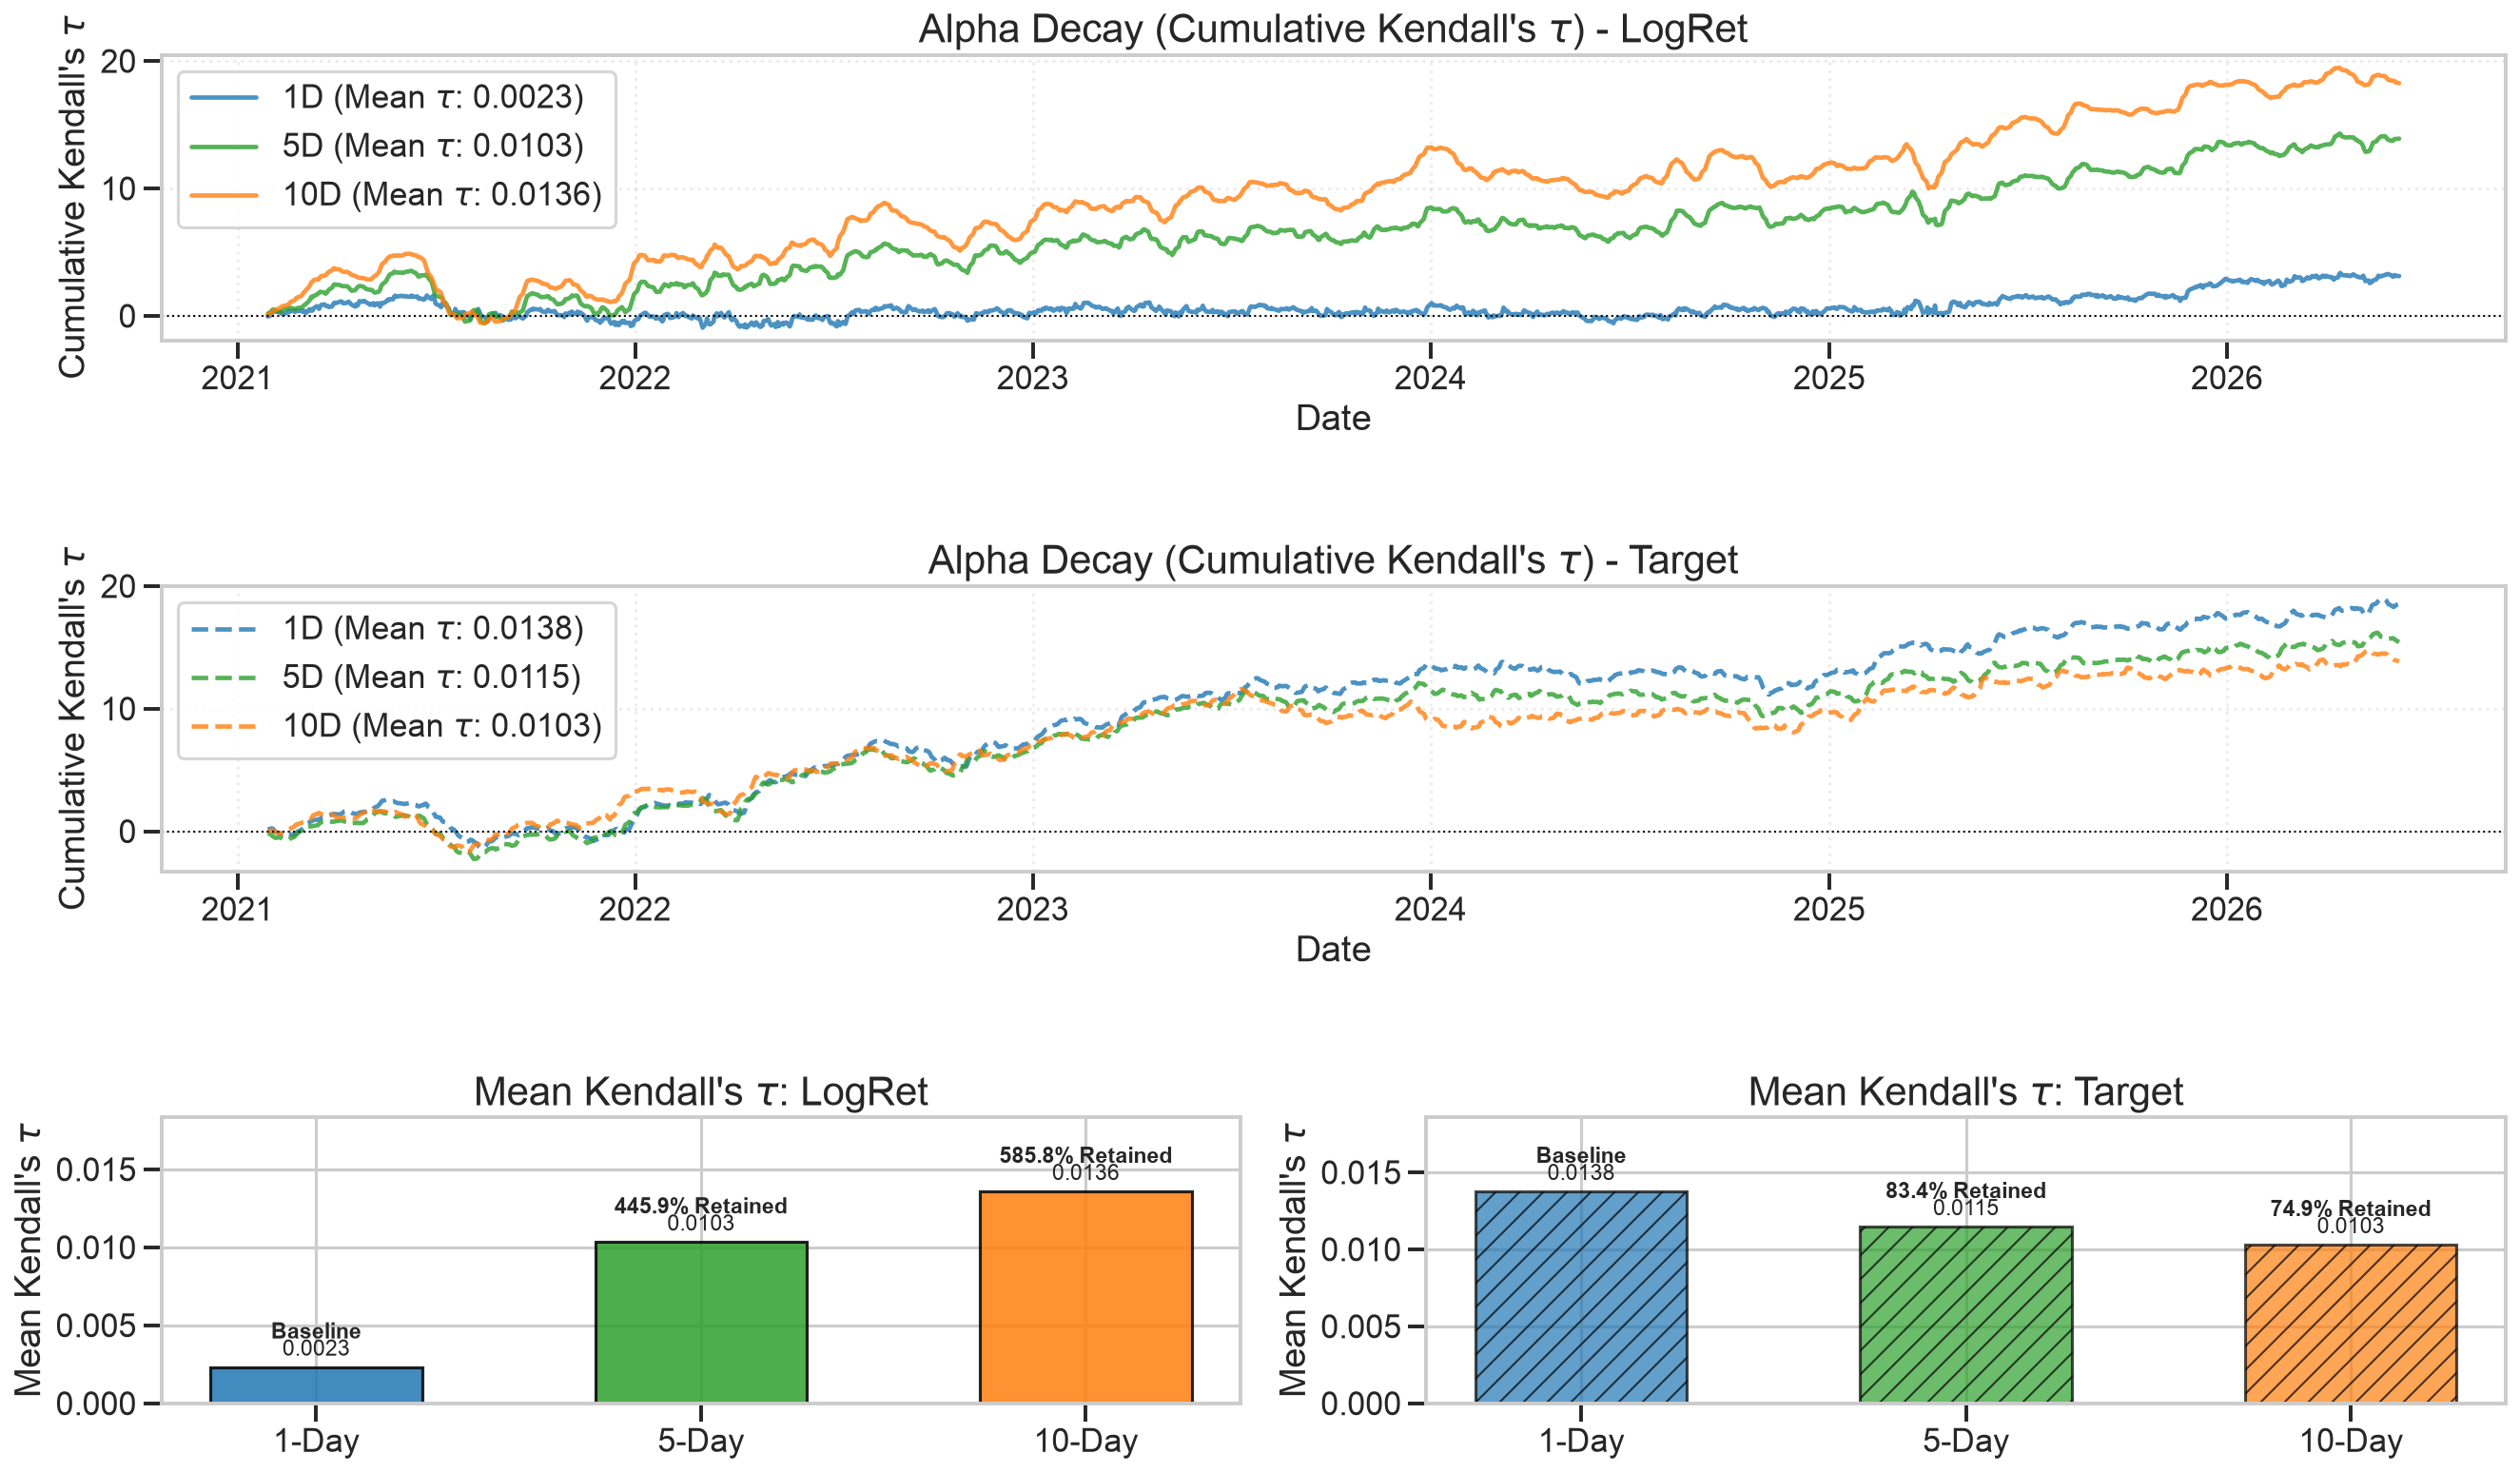

In [12]:
from scipy.stats import kendalltau

# Calculate forward log returns
horizons = [1, 5, 10]

horizons = [1, 5, 10]
logret_df = df.copy().sort_values(['Ticker', 'Date'])

for h in horizons:
    logret_df[f'Fwd_Cum_Ret_{h}D'] = logret_df.groupby('Ticker')['Log_Ret'].transform(
        lambda x: x.rolling(h).sum().shift(-h)
    )
for h in horizons:
    logret_df[f'Ret_Fwd_{h}D'] = logret_df.groupby('Date')[f'Fwd_Cum_Ret_{h}D'].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8)
    )

logret_df = logret_df.dropna(subset=[f'Ret_Fwd_{h}D' for h in horizons] + ['Pred_Alpha'])

daily_tau_logret = []
for date, group in logret_df.groupby('Date'):
    if len(group) > 20 and group['Pred_Alpha'].std() > 1e-6:
        row = {'Date': date}
        valid = True
        for h in horizons:
            tau, _ = kendalltau(group['Pred_Alpha'], group[f'Ret_Fwd_{h}D'])
            if np.isnan(tau):
                valid = False
                break
            row[f'Tau_{h}D'] = tau
        if valid:
            daily_tau_logret.append(row)
tau_logret_df = pd.DataFrame(daily_tau_logret).set_index('Date')

mean_taus_logret = {}
for h in horizons:
    tau_logret_df[f'Cum_Tau_{h}D'] = tau_logret_df[f'Tau_{h}D'].cumsum()
    mean_taus_logret[h] = tau_logret_df[f'Tau_{h}D'].mean()

# Calculate forward target
target_df = df.copy().sort_values(['Ticker', 'Date'])
for h in horizons:
    target_df[f'Target_Lag_{h}D'] = target_df.groupby('Ticker')['Target_5D_Z'].shift(-h)
target_df = target_df.dropna(subset=[f'Target_Lag_{h}D' for h in horizons] + ['Pred_Alpha'])

daily_tau_target = []
for date, group in target_df.groupby('Date'):
    if len(group) > 20 and group['Pred_Alpha'].std() > 1e-6:
        row = {'Date': date}
        valid = True
        for h in horizons:
            tau, _ = kendalltau(group['Pred_Alpha'], group[f'Target_Lag_{h}D'])
            if np.isnan(tau):
                valid = False
                break
            row[f'Tau_{h}D'] = tau
        if valid:
            daily_tau_target.append(row)
tau_target_df = pd.DataFrame(daily_tau_target).set_index('Date')
mean_taus_target = {}
for h in horizons:
    tau_target_df[f'Cum_Tau_{h}D'] = tau_target_df[f'Tau_{h}D'].cumsum()
    mean_taus_target[h] = tau_target_df[f'Tau_{h}D'].mean()

retention_logret_5d = (mean_taus_logret[5] / mean_taus_logret[1]) * 100
retention_logret_10d = (mean_taus_logret[10] / mean_taus_logret[1]) * 100
retention_target_5d = (mean_taus_target[5] / mean_taus_target[1]) * 100
retention_target_10d = (mean_taus_target[10] / mean_taus_target[1]) * 100

fig = plt.figure(figsize=(18, 14))

# Split time series into two separate plots (one for LogRet, one for Target)
ax_ts1 = plt.subplot2grid((4, 2), (0, 0), colspan=2)
ax_ts1.plot(tau_logret_df.index, tau_logret_df['Cum_Tau_1D'], label=f'1D (Mean $\\tau$: {mean_taus_logret[1]:.4f})', color='#1f77b4', linestyle='-', alpha=0.8)
ax_ts1.plot(tau_logret_df.index, tau_logret_df['Cum_Tau_5D'], label=f'5D (Mean $\\tau$: {mean_taus_logret[5]:.4f})', color='#2ca02c', linestyle='-', alpha=0.8)
ax_ts1.plot(tau_logret_df.index, tau_logret_df['Cum_Tau_10D'], label=f'10D (Mean $\\tau$: {mean_taus_logret[10]:.4f})', color='#ff7f0e', linestyle='-', alpha=0.8)
ax_ts1.axhline(0, color='black', linestyle=':', linewidth=1)
ax_ts1.set_title("Alpha Decay (Cumulative Kendall's $\\tau$) - LogRet")
ax_ts1.set_ylabel("Cumulative Kendall's $\\tau$")
ax_ts1.set_xlabel("Date")
ax_ts1.legend(loc='upper left', frameon=True)
ax_ts1.grid(True, linestyle=':', alpha=0.35)

ax_ts2 = plt.subplot2grid((4, 2), (1, 0), colspan=2)
ax_ts2.plot(tau_target_df.index, tau_target_df['Cum_Tau_1D'], label=f'1D (Mean $\\tau$: {mean_taus_target[1]:.4f})', color='#1f77b4', linestyle='--', alpha=0.8)
ax_ts2.plot(tau_target_df.index, tau_target_df['Cum_Tau_5D'], label=f'5D (Mean $\\tau$: {mean_taus_target[5]:.4f})', color='#2ca02c', linestyle='--', alpha=0.8)
ax_ts2.plot(tau_target_df.index, tau_target_df['Cum_Tau_10D'], label=f'10D (Mean $\\tau$: {mean_taus_target[10]:.4f})', color='#ff7f0e', linestyle='--', alpha=0.8)
ax_ts2.axhline(0, color='black', linestyle=':', linewidth=1)
ax_ts2.set_title("Alpha Decay (Cumulative Kendall's $\\tau$) - Target")
ax_ts2.set_ylabel("Cumulative Kendall's $\\tau$")
ax_ts2.set_xlabel("Date")
ax_ts2.legend(loc='upper left', frameon=True)
ax_ts2.grid(True, linestyle=':', alpha=0.35)

# Separate bar plot for LogRet
ax2 = plt.subplot2grid((4, 2), (2, 0))
bar_width = 0.55
lags = ['1-Day', '5-Day', '10-Day']
x = np.arange(len(lags))
vals_logret = [mean_taus_logret[1], mean_taus_logret[5], mean_taus_logret[10]]
b1 = ax2.bar(x, vals_logret, width=bar_width, label='LogRet',
            color=['#1f77b4', '#2ca02c', '#ff7f0e'], alpha=0.85, edgecolor='k')
ax2.set_xticks(x)
ax2.set_xticklabels(lags)
ax2.set_title("Mean Kendall's $\\tau$: LogRet")
ax2.set_ylabel("Mean Kendall's $\\tau$")
ymax = max(vals_logret) * 1.35
ax2.set_ylim(0, ymax)
for idx, val in enumerate(vals_logret):
    ax2.text(x[idx], val + ymax*0.04, f"{val:.4f}", ha='center', fontsize=11)
ax2.text(x[0], vals_logret[0]+ymax*0.10, "Baseline", ha='center', fontsize=11, fontweight='bold')
ax2.text(x[1], vals_logret[1]+ymax*0.10, f"{retention_logret_5d:.1f}% Retained", ha='center', fontsize=11, fontweight='bold')
ax2.text(x[2], vals_logret[2]+ymax*0.10, f"{retention_logret_10d:.1f}% Retained", ha='center', fontsize=11, fontweight='bold')

# Separate bar plot for Target
ax3 = plt.subplot2grid((4, 2), (2, 1))
vals_target = [mean_taus_target[1], mean_taus_target[5], mean_taus_target[10]]
b2 = ax3.bar(x, vals_target, width=bar_width, label='Target',
            color=['#1f77b4', '#2ca02c', '#ff7f0e'], alpha=0.7, edgecolor='k', hatch='//')
ax3.set_xticks(x)
ax3.set_xticklabels(lags)
ax3.set_title("Mean Kendall's $\\tau$: Target")
ax3.set_ylabel("Mean Kendall's $\\tau$")
ymax_t = max(vals_target) * 1.35
ax3.set_ylim(0, ymax_t)
for idx, val in enumerate(vals_target):
    ax3.text(x[idx], val + ymax_t*0.04, f"{val:.4f}", ha='center', fontsize=11)
ax3.text(x[0], vals_target[0]+ymax_t*0.10, "Baseline", ha='center', fontsize=11, fontweight='bold')
ax3.text(x[1], vals_target[1]+ymax_t*0.10, f"{retention_target_5d:.1f}% Retained", ha='center', fontsize=11, fontweight='bold')
ax3.text(x[2], vals_target[2]+ymax_t*0.10, f"{retention_target_10d:.1f}% Retained", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout(h_pad=3)
plt.show()

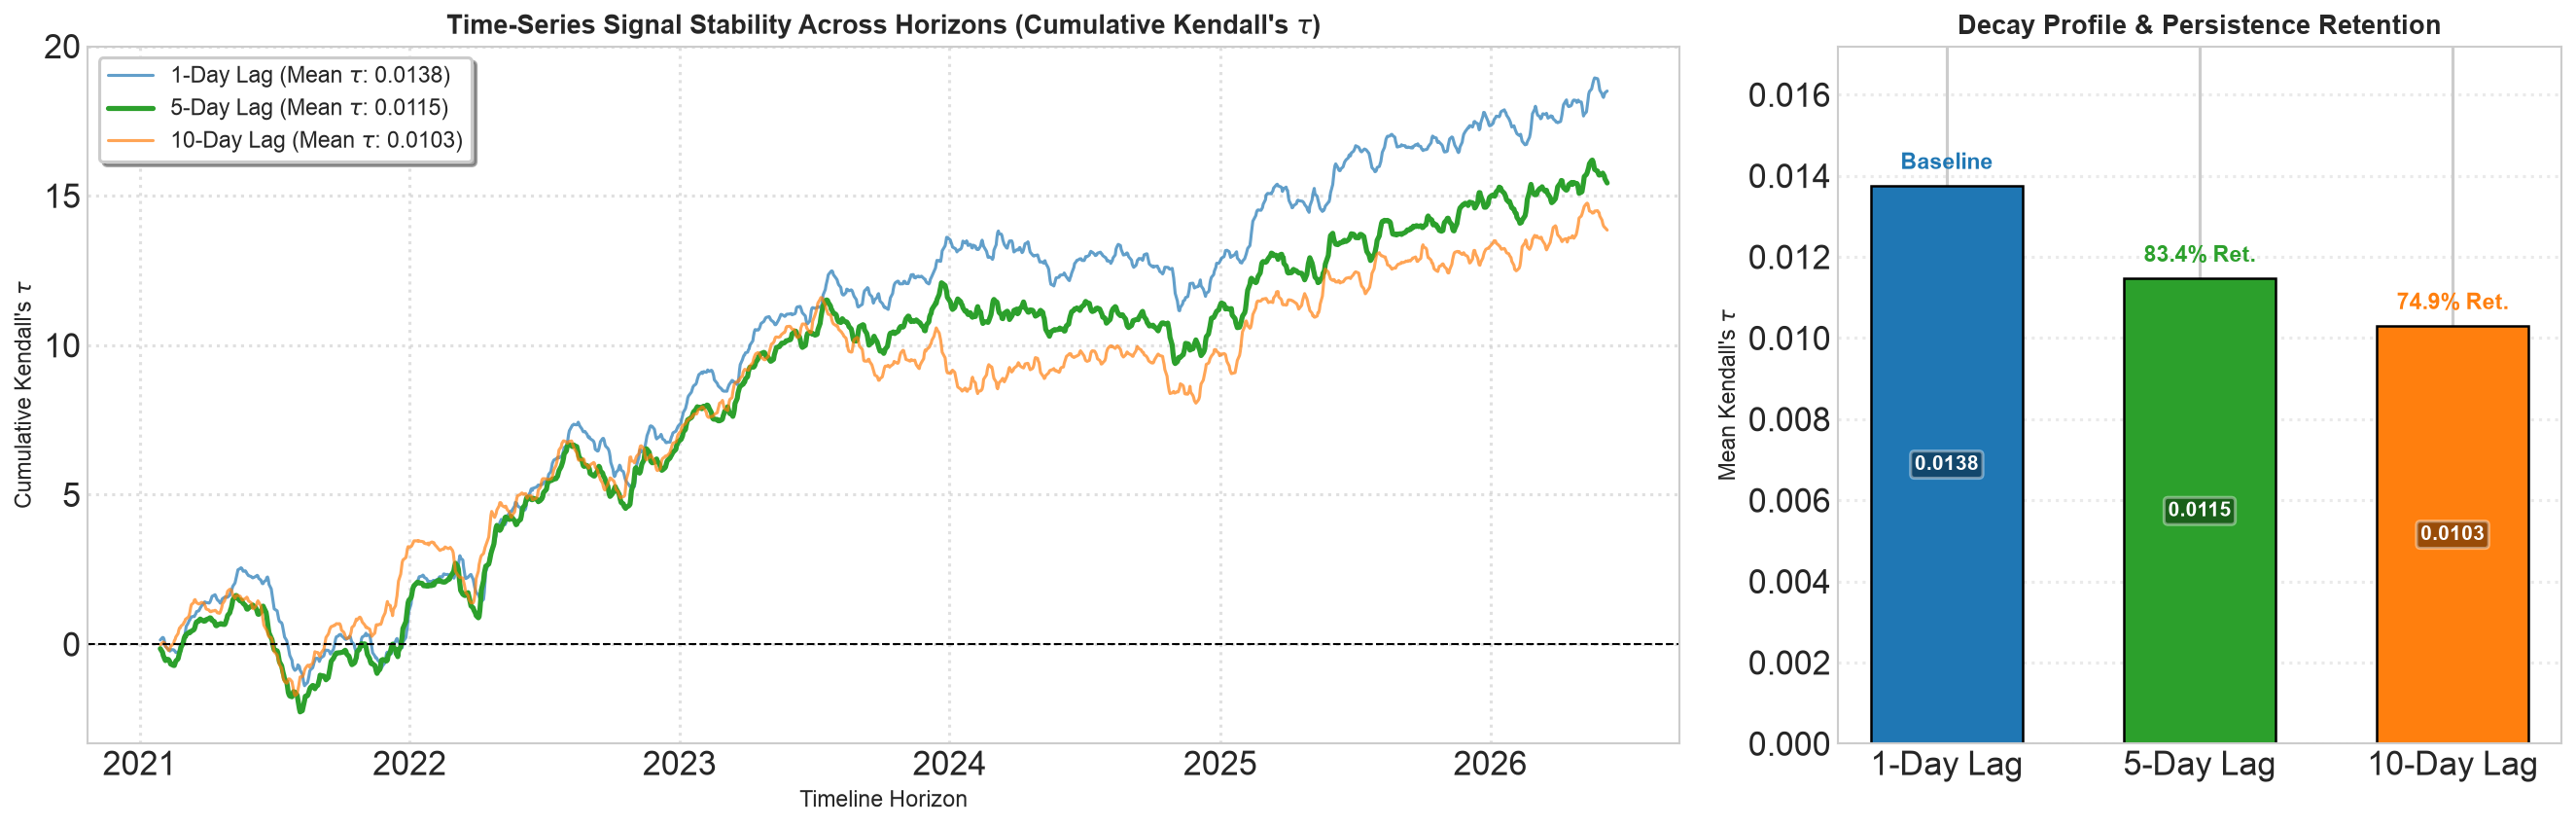

Structural Check: Cumulative Time Series constructed over 1345 total cross-sectional dates.


In [13]:
# ==========================================================================
# ALPHA DECAY & HORIZON STABILITY PROFILE (TIME-SERIES FORMAT)
# ==========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

# Isolate delayed forward windows (specific day decays)
horizons = [1, 5, 10]
decay_df = df.sort_values(['Ticker', 'Date']).copy()

for h in horizons:
    decay_df[f'Ret_Fwd_{h}D'] = decay_df.groupby('Ticker')['Target_5D_Z'].shift(-h)

# Drop boundaries where forward returns cannot be calculated
decay_df = decay_df.dropna(subset=[f'Ret_Fwd_{h}D' for h in horizons] + ['Pred_Alpha'])

# Compute daily Kendall's Tau for each horizon across time
daily_tau = []
for date, group in decay_df.groupby('Date'):
    if len(group) > 20 and group['Pred_Alpha'].std() > 1e-6:
        row = {'Date': date}
        valid = True
        for h in horizons:
            tau, _ = kendalltau(group['Pred_Alpha'], group[f'Ret_Fwd_{h}D'])
            if np.isnan(tau):
                valid = False
                break
            row[f'Tau_{h}D'] = tau

        if valid:
            daily_tau.append(row)

tau_df = pd.DataFrame(daily_tau)
tau_df['Date'] = pd.to_datetime(tau_df['Date'])
tau_df = tau_df.set_index('Date').sort_index()

# Cumulative tau vectors and means
mean_taus = {}
for h in horizons:
    tau_df[f'Cum_Tau_{h}D'] = tau_df[f'Tau_{h}D'].cumsum()
    mean_taus[h] = tau_df[f'Tau_{h}D'].mean()

retention_5d = (mean_taus[5] / mean_taus[1]) * 100
retention_10d = (mean_taus[10] / mean_taus[1]) * 100

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2.2, 1]})

# Plot A: Cumulative Kendall's Tau time series
ax1 = axes[0]
ax1.plot(tau_df.index, tau_df['Cum_Tau_1D'], label=f'1-Day Lag (Mean $\\tau$: {mean_taus[1]:.4f})', color='#1f77b4', linewidth=1.5, alpha=0.7)
ax1.plot(tau_df.index, tau_df['Cum_Tau_5D'], label=f'5-Day Lag (Mean $\\tau$: {mean_taus[5]:.4f})', color='#2ca02c', linewidth=2.5)
ax1.plot(tau_df.index, tau_df['Cum_Tau_10D'], label=f'10-Day Lag (Mean $\\tau$: {mean_taus[10]:.4f})', color='#ff7f0e', linewidth=1.5, alpha=0.7)
ax1.axhline(0, color='black', linestyle='--', linewidth=1)
ax1.set_title("Time-Series Signal Stability Across Horizons (Cumulative Kendall's $\\tau$)", fontsize=13, fontweight='bold')
ax1.set_ylabel("Cumulative Kendall's $\\tau$", fontsize=11)
ax1.set_xlabel("Timeline Horizon", fontsize=11)
ax1.legend(loc='upper left', frameon=True, shadow=True, fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot B: Persistence bar chart
ax2 = axes[1]
y_values = [mean_taus[1], mean_taus[5], mean_taus[10]]
bars = ax2.bar(['1-Day Lag', '5-Day Lag', '10-Day Lag'], y_values, 
               color=['#1f77b4', '#2ca02c', '#ff7f0e'], edgecolor='black', linewidth=1.2, width=0.6)

ax2.set_title("Decay Profile & Persistence Retention", fontsize=13, fontweight='bold')
ax2.set_ylabel("Mean Kendall's $\\tau$", fontsize=11)
ax2.set_ylim(0, max(y_values) * 1.25)
ax2.grid(True, linestyle=':', alpha=0.4, axis='y')

ax2.text(0, mean_taus[1] + (max(y_values)*0.03), 'Baseline', ha='center', fontsize=11, fontweight='bold', color='#1f77b4')
ax2.text(1, mean_taus[5] + (max(y_values)*0.03), f'{retention_5d:.1f}% Ret.', ha='center', fontsize=11, fontweight='bold', color='#2ca02c')
ax2.text(2, mean_taus[10] + (max(y_values)*0.03), f'{retention_10d:.1f}% Ret.', ha='center', fontsize=11, fontweight='bold', color='#ff7f0e')

# Value annotations inside bars
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval / 2, f'{yval:.4f}', ha='center', va='center', 
             fontsize=10, fontweight='bold', color='white', bbox=dict(facecolor='black', alpha=0.4, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()

print(f"Structural Check: Cumulative Time Series constructed over {len(tau_df)} total cross-sectional dates.")


In [14]:
# STATISTICAL SIGNIFICANCE & CONSISTENCY (HAC ROBUST)
import statsmodels.api as sm

# % of Positive IC Periods
positive_ic_pct = (ic_df['IC'] > 0).mean() * 100

# Newey-West Adjusted T-Statistic with maxlags=5 (to penalize 5-day overlap)
Y = ic_df['IC'].values
X = np.ones(len(Y))

nw_model = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
nw_mean_ic = nw_model.params[0]
nw_tstat = nw_model.tvalues[0]
nw_pvalue = nw_model.pvalues[0]

print("SIGNAL CONSISTENCY & SIGNIFICANCE")
print(f"Percentage of Positive IC Days : {positive_ic_pct:.2f}%")
print(f"Mean IC (OLS)                  : {nw_mean_ic:.5f}")
print(f"Newey-West T-Statistic (lag=5) : {nw_tstat:.3f}")
print(f"Newey-West P-Value             : {nw_pvalue:.5e}")

if nw_tstat > 2.0:
    print("-> Result: HIGHLY SIGNIFICANT (Null Hypothesis of 0 IC Rejected)")
else:
    print("-> Result: INSIGNIFICANT (Fails Autocorrelation Robustness)")

SIGNAL CONSISTENCY & SIGNIFICANCE
Percentage of Positive IC Days : 55.42%
Mean IC (OLS)                  : 0.02088
Newey-West T-Statistic (lag=5) : 3.229
Newey-West P-Value             : 1.24020e-03
-> Result: HIGHLY SIGNIFICANT (Null Hypothesis of 0 IC Rejected)


In [15]:
# Deflated Sharpe Ratio (multiple-testing adjusted overfitting check)
import scipy.stats as st

def calculate_dsr(gross_returns, n_trials, trial_sharpes_variance):
    """
    Estimated Deflated Sharpe Ratio (DSR) that adjusts for non-normality and multiple-testing bias.
    """
    ann_ret = gross_returns.mean() * (252 / 5)
    ann_vol = gross_returns.std() * np.sqrt(252 / 5)
    obs_sharpe = ann_ret / ann_vol

    # Skewness and kurtosis for adjustment
    skew = st.skew(gross_returns.dropna())
    kurt = st.kurtosis(gross_returns.dropna(), fisher=False)

    # Expected maximum Sharpe for n_trials (Bailey & Lopez de Prado)
    euler = 0.5772156649
    if n_trials > 1:
        max_Z = (1 - euler) * st.norm.ppf(1 - 1/n_trials) + euler * st.norm.ppf(1 - 1/(n_trials * np.e))
        expected_max_sr = np.sqrt(trial_sharpes_variance) * max_Z
    else:
        expected_max_sr = 0.0

    n_periods = len(gross_returns)
    denominator = np.sqrt(1 - (skew * obs_sharpe) + ((kurt - 1) / 4) * (obs_sharpe**2))
    dsr_stat = (obs_sharpe - expected_max_sr) * np.sqrt(n_periods) / denominator
    dsr_prob = st.norm.cdf(dsr_stat)
    
    return obs_sharpe, expected_max_sr, dsr_prob

# Approx variance from 5 Optuna Sharpe ratios
optuna_sharpe_variance = np.var([1.5, 1.6, 2.5, 0.7, 0.9]) 

obs_sr, exp_max_sr, dsr_prob = calculate_dsr(pnl_df_fixed['Gross_Ret'], n_trials=5, trial_sharpes_variance=optuna_sharpe_variance)

print("="*50)
print("DEFLATED SHARPE RATIO (DSR) ANALYSIS")
print("="*50)
print(f"Observed Gross Sharpe Ratio  : {obs_sr:.3f}")
print(f"Expected Max SR (from noise) : {exp_max_sr:.3f}")
print(f"Deflated Sharpe Probability  : {dsr_prob * 100:.2f}%")
if dsr_prob > 0.95:
    print("-> Result: ROBUST (Not an artifact of Optuna overfitting)")
else:
    print("-> Result: OVERFIT WARNING (Failed to clear expected noise hurdle)")
print("="*50)

DEFLATED SHARPE RATIO (DSR) ANALYSIS
Observed Gross Sharpe Ratio  : 0.439
Expected Max SR (from noise) : 0.753
Deflated Sharpe Probability  : 0.00%
-> Result: OVERFIT WARNING (Failed to clear expected noise hurdle)


## Factor-Neutral Stress Test (PCA Orthogonalization)


Running neutralization of model signal against market factor...
FACTOR-NEUTRAL DECILE SPREADS
Original Decile Monotonicity  : 0.9515
Neutralized Monotonicity      : 0.9515
The signal remains meaningfully stock-specific, not just market-driven.


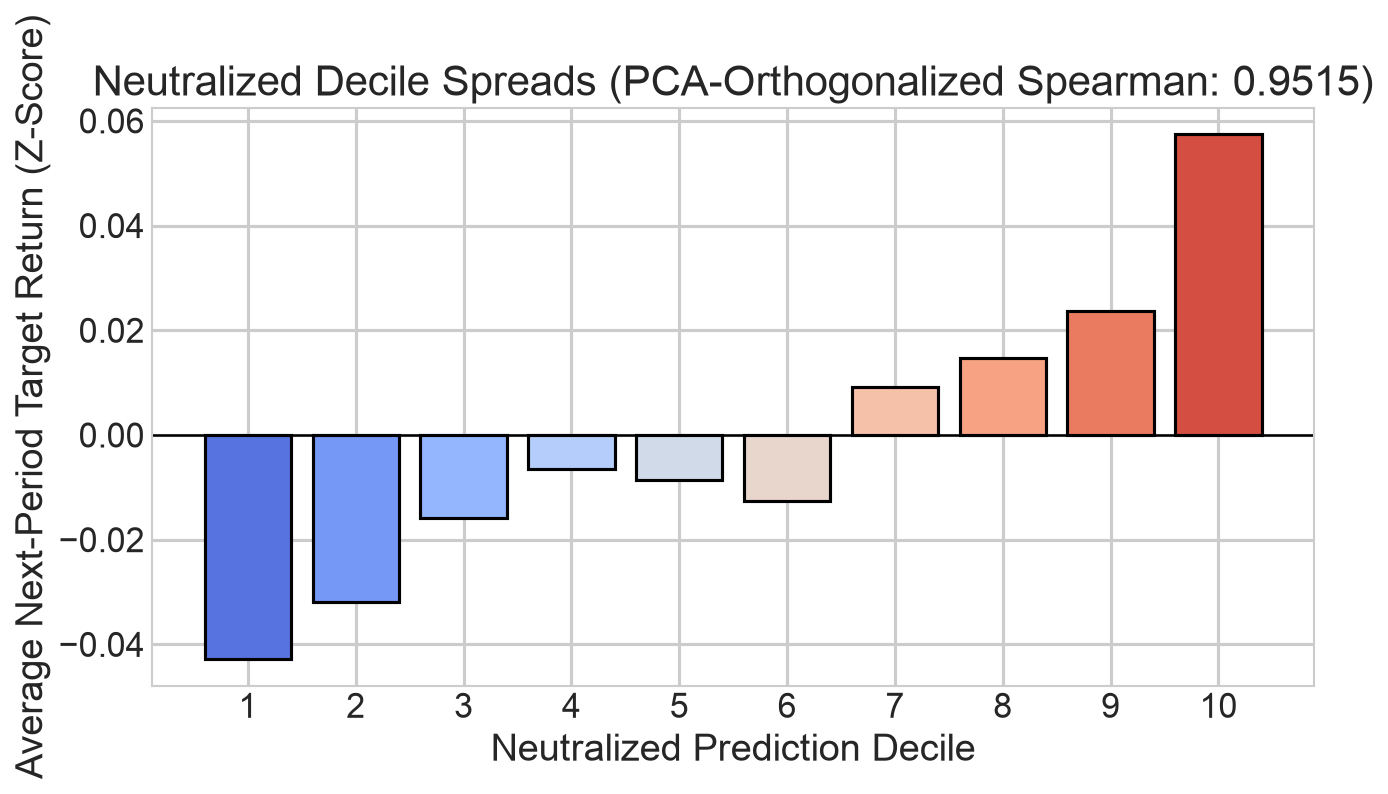

In [16]:
from sklearn.decomposition import PCA

# Use PCA to extract the top market mode from the full panel of log returns.
returns_matrix = df.pivot(index='Date', columns='Ticker', values='Log_Ret').fillna(0)
pca = PCA(n_components=1)
pca.fit(returns_matrix.values)

# First principal component captures market's common movement
market_loadings = pd.Series(pca.components_[0], index=returns_matrix.columns)
df['PCA_Mkt_Beta'] = df['Ticker'].map(market_loadings)

# Remove (neutralize) the main market factor from the model signal via cross-sectional regression
def neutralize_market_effect(group):
    X = sm.add_constant(group['PCA_Mkt_Beta'].values)
    y = group['Pred_Alpha'].values
    try:
        model = sm.OLS(y, X).fit()
        # Residuals represent the component of signal unexplained by market
        return pd.Series(model.resid, index=group.index)
    except Exception:
        # If regression fails, just return the unadjusted values (rare)
        return pd.Series(y, index=group.index)

print("Running neutralization of model signal against market factor...")
df['Neutral_Pred_Alpha'] = df.groupby('Date', group_keys=False).apply(neutralize_market_effect)

# Rank and decile assign the neutralized alphas daily
df['Neutral_Rank'] = df.groupby('Date')['Neutral_Pred_Alpha'].rank(method='first')
df['Neutral_Decile'] = df.groupby('Date')['Neutral_Rank'].transform(
    lambda x: pd.qcut(x, 10, labels=False) + 1
)

neutral_decile_returns = df.groupby('Neutral_Decile')['Target_5D_Z'].mean()
neutral_mono_corr, _ = spearmanr(neutral_decile_returns.index, neutral_decile_returns.values)

print("FACTOR-NEUTRAL DECILE SPREADS")
print(f"Original Decile Monotonicity  : {mono_corr:.4f}")
print(f"Neutralized Monotonicity      : {neutral_mono_corr:.4f}")

if neutral_mono_corr > 0.80:
    print("The signal remains meaningfully stock-specific, not just market-driven.")
else:
    print("Caution: The model's signal appears to depend a lot on market direction.")

# Plot neutralized decile returns
plt.figure(figsize=(10, 5))
colors = sns.color_palette("coolwarm", len(neutral_decile_returns))
bars = plt.bar(neutral_decile_returns.index, neutral_decile_returns.values, color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=1.2)
plt.title(f"Neutralized Decile Spreads (PCA-Orthogonalized Spearman: {neutral_mono_corr:.4f})")
plt.xlabel("Neutralized Prediction Decile")
plt.ylabel("Average Next-Period Target Return (Z-Score)")
plt.xticks(range(1, 11))
plt.show()